# Conditional Distribution Path

---
---
# 1: Implementing Conditional Probability Paths
Recall from lecture and the class notes the basic premise of conditional flow matching: describe a *conditional probability path* $p_t(x|z)$, so that $p_1(x|z) = \delta_z(x)$, and $p_0(z) = p_{\text{simple}}$ (e.g., a Gaussian), and $p_t(x|z)$ interpolates continuously (we are not being rigorous here) between $p_0(x|z)$ and $p_1(x|z)$. Such a conditional path can be seen as corresponding to some corruption process which (in reverse time) drives the point $z$ at $t=1$ to be distribution as $p_0(x|z)$ at time $t=0$. Such a corruption process is given by the ODE
$$dX_t = u_t^{\text{ref}}(X_t|z)\,dt,\quad \quad X_0 \sim p_{\text{simple}}.$$
The drift $u_t^{\text{ref}}(X_t|z)$ is referred to as the *conditional vector field*. By averaging $u_t^{\text{ref}}(x|z)$ over all such choices of $z$, we obtain the *marginal* vector field $u_t^{\text{ref}}(x)$. Flow matching proposes to exploit the fact that the *marginal probability path* $p_t(x)$ generated by the marginal vector field $u_t^{\text{ref}}(x)$, bridges $p_{\text{simple}}$ to $p_{\text{data}}$. Since the conditional vector field $u_t^{\text{ref}}(x|z)$ is often analytically available, we may implicitly regress against the unknown marginal vector field $u_t^{\text{ref}}(x)$ by explicitly regressing against the conditional vector field $u_t^{\text{ref}}(x|z)$.

The central object in this construction is a *conditional probability path*, whose interface is implemented below in the class `ConditionalProbabilityPath`. In this lab, you will implement two subclasses: `GaussianConditionalProbabilityPath`, and `LinearConditionalProbabilityPath` corresponding to probability paths of the same names from the lectures and notes.


---
## 1.1 Create New Samplers

In [4]:
import torch
import numpy as np
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict
from sklearn.datasets import make_moons, make_circles

from fmtorch.distribution import Density
from fmtorch.sampler import Sampler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
class MoonsSampler(Sampler):
    """
    Implementation of the Moons distribution using sklearn's make_moons
    """
    def __init__(self, device: torch.device, noise: float = 0.05, scale: float = 5.0, offset: Optional[torch.Tensor] = None):
        """
        Args:
            noise: Standard deviation of Gaussian noise added to the data
            scale: How much to scale the data
            offset: How much to shift the samples from the original distribution (2,)
        """
        self.noise = noise
        self.scale = scale
        self.device = device
        if offset is None:
            offset = torch.zeros(2)
        self.offset = offset.to(device)

    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: Number of samples to generate
        Returns:
            torch.Tensor: Generated samples with shape (num_samples, 3)
        """
        samples, _ = make_moons(
            n_samples=num_samples,
            noise=self.noise,
            random_state=None  # Allow for random generation each time
        )
        return self.scale * torch.from_numpy(samples.astype(np.float32)).to(self.device) + self.offset

class CirclesSampleable(Sampler):
    """
    Implementation of concentric circle distribution using sklearn's make_circles
    """
    def __init__(self, device: torch.device, noise: float = 0.05, scale=5.0, offset: Optional[torch.Tensor] = None):
        """
        Args:
            noise: standard deviation of Gaussian noise added to the data
        """
        self.noise = noise
        self.scale = scale
        self.device = device
        if offset is None:
            offset = torch.zeros(2)
        self.offset = offset.to(device)

    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 3)
        """
        samples, _ = make_circles(
            n_samples=num_samples,
            noise=self.noise,
            factor=0.5,
            random_state=None
        )
        return self.scale * torch.from_numpy(samples.astype(np.float32)).to(self.device) + self.offset

class CheckerboardSampler(Sampler):
    """
    Checkboard-esque distribution
    """
    def __init__(self, device: torch.device, grid_size: int = 3, scale=5.0):
        """
        Args:
            noise: standard deviation of Gaussian noise added to the data
        """
        self.grid_size = grid_size
        self.scale = scale
        self.device = device

    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 3)
        """
        grid_length = 2 * self.scale / self.grid_size
        samples = torch.zeros(0,2).to(device)
        while samples.shape[0] < num_samples:
            # Sample num_samples
            new_samples = (torch.rand(num_samples,2).to(self.device) - 0.5) * 2 * self.scale
            x_mask = torch.floor((new_samples[:,0] + self.scale) / grid_length) % 2 == 0 # (bs,)
            y_mask = torch.floor((new_samples[:,1] + self.scale) / grid_length) % 2 == 0 # (bs,)
            accept_mask = torch.logical_xor(~x_mask, y_mask)
            samples = torch.cat([samples, new_samples[accept_mask]], dim=0)
        return samples[:num_samples]


---
## 1.2 Gaussian Conditional Probability Path


In this section, we'll implement a **Gaussian conditional probability path** via the class `GaussianConditionalProbabilityPath`. We will then use it to transform a simple source $p_{\text{simple}} = N(0, I_d)$ into a Gaussian mixture $p_{\text{data}}$. Later, we'll experiment with more exciting distributions. Recall that a Gaussian conditional probability path is given by
$$p_t(x|z) = N(x;\alpha_t z,\beta_t^2 I_d),\quad\quad\quad p_{\text{simple}}=N(0,I_d),$$
where $\alpha_t: [0,1] \to \mathbb{R}$ and $\beta_t: [0,1] \to \mathbb{R}$ are monotonic, continuously differentiable functions satisfying $\alpha_1 = \beta_0 = 1$ and $\alpha_0 = \beta_1 = 0$. In other words, this implies that $p_1(x|z) = \delta_z$ and $p_0(x|z) = N(0, I_d)$ is a unit Gaussian. Before we dive into things, let's take a look at $p_{\text{simple}}$ and $p_{\text{data}}$. 

In [6]:
from fmtorch.sampler import GaussianSampler, GaussianMixtureSampler

### Visualization 

In [7]:
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes

def imshow_density(density: Density, x_bounds: Tuple[float, float], y_bounds: Tuple[float, float], bins: int, ax: Optional[Axes] = None, x_offset: float = 0.0, **kwargs):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = x_bounds
    y_min, y_max = y_bounds
    x = torch.linspace(x_min, x_max, bins).to(device) + x_offset
    y = torch.linspace(y_min, y_max, bins).to(device)
    X, Y = torch.meshgrid(x, y)
    xy = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)
    density = density.log_density(xy).reshape(bins, bins).T
    im = ax.imshow(density.cpu(), extent=[x_min, x_max, y_min, y_max], origin='lower', **kwargs)

/Users/zewen/Documents/alwinyang/fmtorch/.venv/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


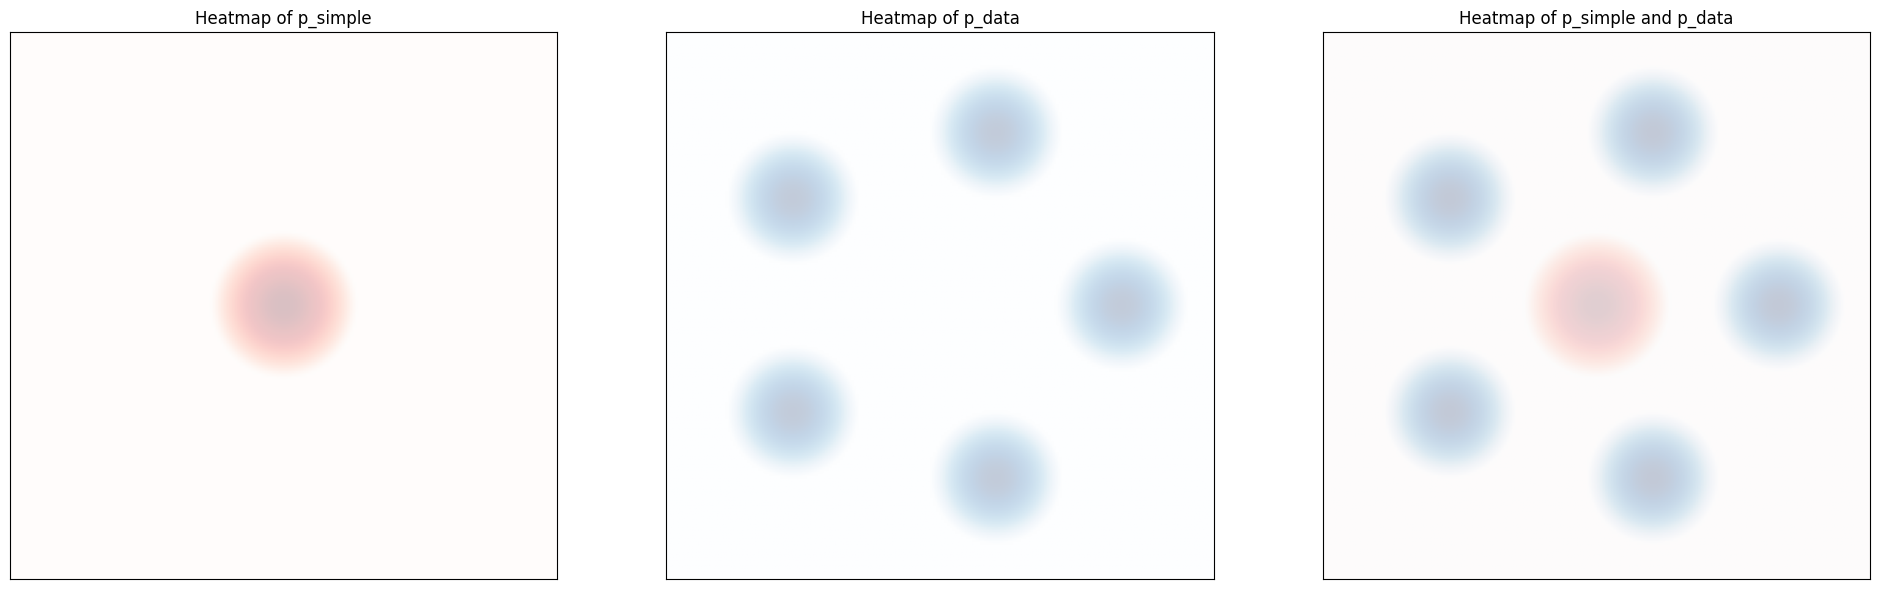

In [10]:
# Constants for the duration of our use of Gaussian conditional probability paths, to avoid polluting the namespace...
PARAMS = {
    "scale": 15.0,
    "target_scale": 10.0,
    "target_std": 1.0,
}

# p_sample_init = Gaussian.isotropic(dim=2, std = 1.0).to(device) # same results
p_sample_init = GaussianSampler(mean=torch.zeros(2), cov=1.0 * torch.eye(2)).to(device)

p_target_finial = GaussianMixtureSampler.symmetric_2D(nmodes=5, std=PARAMS["target_std"], scale_mean=PARAMS["target_scale"]).to(device)

fig, axes = plt.subplots(1,3, figsize=(24,8))
bins = 200

scale = PARAMS["scale"]
x_bounds = [-scale,scale]
y_bounds = [-scale,scale]

axes[0].set_title('Heatmap of p_simple')
axes[0].set_xticks([])
axes[0].set_yticks([])
imshow_density(density=p_sample_init, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=axes[0], vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))


axes[1].set_title('Heatmap of p_data')
axes[1].set_xticks([])
axes[1].set_yticks([])
imshow_density(density=p_target_finial, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, ax=axes[1], vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

axes[2].set_title('Heatmap of p_simple and p_data')
axes[2].set_xticks([])
axes[2].set_yticks([])
imshow_density(density=p_sample_init, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Reds'))
imshow_density(density=p_target_finial, x_bounds=x_bounds, y_bounds=y_bounds, bins=200, vmin=-10, alpha=0.25, cmap=plt.get_cmap('Blues'))

### Problem 2.1: Implementing $\alpha_t$ and $\beta_t$ 

Let's get started by implementing $\alpha_t$ and $\beta_t$. We can think of these simply as callable objects which fulfill the simple contract $\alpha_1 = \beta_0 = 1$ and $\alpha_0 = \beta_1 = 0$, and which can compute their time derivatives $\dot{\alpha}_t$ and $\dot{\beta}_t$. We implement them below via the classes `Alpha` and `Beta`.

In [ ]:
from torch.func import vmap, jacrev
class Alpha(ABC):
    def __init__(self):
        # Check alpha_t(0) = 0
        assert torch.allclose(
            self(torch.zeros(1,1)), torch.zeros(1,1)
        )
        # Check alpha_1 = 1
        assert torch.allclose(
            self(torch.ones(1,1)), torch.ones(1,1)
        )
        
    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 0.0, self(1.0) = 1.0.
        Args:
            - t: time (num_samples, 1)
        Returns:
            - alpha_t (num_samples, 1)
        """ 
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1)
        """ 
        t = t.unsqueeze(1) # (num_samples, 1, 1)
        dt = vmap(jacrev(self))(t) # (num_samples, 1, 1, 1, 1)
        return dt.view(-1, 1)
    
class Beta(ABC):
    def __init__(self):
        # Check beta_0 = 1
        assert torch.allclose(
            self(torch.zeros(1,1)), torch.ones(1,1)
        )
        # Check beta_1 = 0
        assert torch.allclose(
            self(torch.ones(1,1)), torch.zeros(1,1)
        )
        
    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 1.0, self(1.0) = 0.0.
        Args:
            - t: time (num_samples, 1)
        Returns:
            - beta_t (num_samples, 1)
        """ 
        pass 

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt beta_t.
        Args:
            - t: time (num_samples, 1)
        Returns:
            - d/dt beta_t (num_samples, 1)
        """ 
        t = t.unsqueeze(1) # (num_samples, 1, 1)
        dt = vmap(jacrev(self))(t) # (num_samples, 1, 1, 1, 1)
        return dt.view(-1, 1)

### Linear $\alpha_t$ and $\beta_t$

In this section, we'll be using $$\alpha_t = t \quad \quad \text{and} \quad \quad \beta_t = \sqrt{1-t}.$$ It is not hard to check that both functions are continuously differentiable on $[0,1)$, and monotonic, that $\alpha_1 = \beta_0 = 1$, and that $\alpha_0 = \beta_1 = 0$.

**Your job**: Implement the `__call__` methods of the classes `LinearAlpha` and `SquareRootBeta` below.

In [ ]:
class LinearAlpha(Alpha):
    """
    Implements alpha_t = t
    """
    
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: time (num_samples, 1)
        Returns:
            - alpha_t (num_samples, 1)
        """ 
        return t
        
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1)
        """ 
        return torch.ones_like(t)

class SquareRootBeta(Beta):
    """
    Implements beta_t = rt(1-t)
    """
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: time (num_samples, 1)
        Returns:
            - beta_t (num_samples, 1)
        """ 
        return torch.sqrt(1 - t)

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1)
        """ 
        return - 0.5 / (torch.sqrt(1 - t) + 1e-4)

## 1.4 Define the sample functions GaussianConditionalProbabilityPath class